# 05. Les spécialistes par famille auraient-ils fait mieux sur 2012 ?

Comparaison, **à titre exploratoire**, entre le modèle global final de 04 et des CatBoost spécialisés par `ProductGroup`, sur exactement les mêmes ventes de 2012.

**Statut de cette comparaison :** le résultat du test 2012 a déjà été observé dans 04. Ce notebook ne constitue donc pas une validation indépendante permettant de choisir une architecture. Le modèle global, retenu pour sa simplicité d'exploitation, et les résultats de 04 restent inchangés.

Prérequis : avoir terminé `04 - Modelisation finale.ipynb`. Exécuter ensuite les cellules dans l'ordre, avec le noyau du projet. Les spécialistes sont entraînés au premier passage puis sauvegardés ; les passages suivants rechargent les modèles et le rapport.

## Même préparation, mêmes ventes, mêmes paramètres

On recharge la préparation A et le modèle global déjà entraînés dans 04. La préparation a appris ses statistiques sur les ventes antérieures à 2012. Elle reste figée : on applique seulement `transform`.

Chaque spécialiste apprend sur les ventes de sa famille antérieures à 2012, avec les paramètres de 04. `ProductGroup` est retiré de ses variables, puisqu'il est constant à l'intérieur de cette famille. Il reste présent dans les variables du global.

Il y aura six spécialistes sur ce jeu de données. Le global de 04 sert de repli pour une famille inconnue ou comptant moins de 200 ventes d'apprentissage. Aucun réglage n'utilise les scores 2012.

In [1]:
from pathlib import Path
import sys
import json
import pickle
import time
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src/preparation_03.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Passer à False pour recharger les spécialistes déjà entraînés.
REENTRAINER = True

DOSSIER_GLOBAL = ROOT / "resultats/modele_final_global_A"
FICHIER_GLOBAL = DOSSIER_GLOBAL / "modele_final.pkl"
assert FICHIER_GLOBAL.exists(), "Exécuter d'abord 04 pour entraîner le global."

with FICHIER_GLOBAL.open("rb") as fichier:
    sauvegarde_globale = pickle.load(fichier)
preparation_finale = sauvegarde_globale["preparation"]
modele_global = sauvegarde_globale["modele"]
rapport_global = json.loads((DOSSIER_GLOBAL / "evaluation_test.json").read_text(encoding="utf-8"))

PARAMS = dict(iterations=500, depth=6, learning_rate=0.1,
              loss_function="RMSE", random_seed=2012,
              thread_count=8, verbose=100, allow_writing_files=False)
MIN_SEGMENT = 200
DOSSIER_SEGMENTE = ROOT / "resultats/modele_segmente_exploratoire_A"
DOSSIER_SEGMENTE.mkdir(parents=True, exist_ok=True)
FICHIER_SEGMENTE = DOSSIER_SEGMENTE / "specialistes.pkl"
print("Global de 04 rechargé — RMSLE test 2012 :", round(rapport_global["rmsle"], 5))

Global de 04 rechargé — RMSLE test 2012 : 0.24043


## Reprendre l'apprentissage complet

Les spécialistes doivent apprendre sur exactement les mêmes ventes que le global de 04, avec exactement la même préparation. On recharge donc le fichier brut et on réapplique la préparation sauvegardée, sans jamais la réajuster.

In [2]:
RAW = ROOT / "data/raw/bluebook-for-bulldozers/TrainAndValid.csv"
df = pd.read_csv(RAW, low_memory=False)
# Même format imposé que dans 03 et 04.
df["saledate"] = pd.to_datetime(df["saledate"], format="%m/%d/%Y %H:%M")
train_final = df.loc[df["saledate"] < "2012-01-01"].sort_values("saledate", kind="stable").copy()

# Mêmes ventes d'apprentissage que le global de 04, et préparation figée avant 2012.
assert len(train_final) == preparation_finale.n_fit_ == rapport_global["n_train"]
assert preparation_finale.fit_max_date_ < pd.Timestamp("2012-01-01")

X_train_final = preparation_finale.transform(train_final)
y_train_final = np.log1p(train_final["SalePrice"])
variables_segment = X_train_final.columns.drop("ProductGroup").tolist()
cat_features_segment = [col for col in preparation_finale.cat_features_ if col != "ProductGroup"]
print(f"Apprentissage : {len(train_final):,} ventes")
display(X_train_final["ProductGroup"].value_counts().rename("n_apprentissage"))

Apprentissage : 401,125 ventes


ProductGroup
TEX    101167
TTT     80520
BL      79415
WL      71046
SSL     43488
MG      25489
Name: n_apprentissage, dtype: int64

## Entraînement des spécialistes

Une boucle par famille, les mêmes paramètres que 04, et aucun accès au test : ni `eval_set`, ni arrêt anticipé.

Le coût affiché est celui des spécialistes seuls. Le global de secours existe déjà grâce à 04, il n'est pas réentraîné ici. Le budget de 500 itérations s'applique à chaque spécialiste, pas à l'ensemble : six spécialistes disposent donc de plus de capacité que le modèle unique.

In [3]:
if REENTRAINER:
    modeles_segment = {}
    durees_segment = []
    for groupe in sorted(X_train_final["ProductGroup"].unique()):
        mask_train = X_train_final["ProductGroup"] == groupe
        if mask_train.sum() < MIN_SEGMENT:
            print(f"{groupe} : apprentissage insuffisant, repli global prévu.")
            continue
        print(f"Entraînement {groupe} : {mask_train.sum():,} ventes")
        debut = time.perf_counter()
        model_segment = CatBoostRegressor(**PARAMS)
        model_segment.fit(X_train_final.loc[mask_train, variables_segment],
                          y_train_final.loc[mask_train], cat_features=cat_features_segment)
        modeles_segment[groupe] = model_segment
        durees_segment.append({"segment": groupe, "n_train": int(mask_train.sum()),
                               "secondes": time.perf_counter() - debut})

    with FICHIER_SEGMENTE.open("wb") as fichier:
        pickle.dump({"modeles": modeles_segment, "durees": durees_segment}, fichier)
    print("Spécialistes enregistrés :", FICHIER_SEGMENTE)
else:
    with FICHIER_SEGMENTE.open("rb") as fichier:
        sauvegarde_segmentee = pickle.load(fichier)
    modeles_segment = sauvegarde_segmentee["modeles"]
    durees_segment = sauvegarde_segmentee["durees"]
    print("Spécialistes rechargés.")

print(f"{len(modeles_segment)} spécialistes + le global de 04 pour le repli")
display(pd.DataFrame(durees_segment))

Entraînement BL : 79,415 ventes
0:	learn: 0.3674921	total: 194ms	remaining: 1m 36s
100:	learn: 0.1623630	total: 17.8s	remaining: 1m 10s
200:	learn: 0.1526482	total: 38.5s	remaining: 57.2s
300:	learn: 0.1485470	total: 1m	remaining: 40s
400:	learn: 0.1457139	total: 1m 22s	remaining: 20.4s
499:	learn: 0.1435457	total: 1m 44s	remaining: 0us
Entraînement MG : 25,489 ventes
0:	learn: 0.7017480	total: 128ms	remaining: 1m 3s
100:	learn: 0.2063188	total: 13.9s	remaining: 54.9s
200:	learn: 0.1918731	total: 28s	remaining: 41.7s
300:	learn: 0.1853001	total: 42.4s	remaining: 28s
400:	learn: 0.1799328	total: 57.5s	remaining: 14.2s
499:	learn: 0.1757220	total: 1m 13s	remaining: 0us
Entraînement SSL : 43,488 ventes
0:	learn: 0.3240245	total: 178ms	remaining: 1m 28s
100:	learn: 0.1878049	total: 16.4s	remaining: 1m 4s
200:	learn: 0.1791135	total: 33.4s	remaining: 49.6s
300:	learn: 0.1750274	total: 52.5s	remaining: 34.7s
400:	learn: 0.1724047	total: 1m 8s	remaining: 17s
499:	learn: 0.1701487	total: 1m 26

,segment,n_train,secondes
0,BL,79415,106.294839
1,MG,25489,75.322826
2,SSL,43488,88.721254
3,TEX,101167,204.853595
4,TTT,80520,132.684628
5,WL,71046,124.253730


## Prédictions et comparaison sur les mêmes ventes

Les prédictions partent de celles du global. Chaque spécialiste remplace seulement celles de sa famille ; les lignes sans spécialiste gardent le global et restent dans le score total.

Le contrôle qui compte ici : les deux architectures doivent être jugées sur **exactement les mêmes ventes**. On recoupe donc les `SalesID` et les prédictions globales avec les prédictions exportées par 04 avant de comparer quoi que ce soit.

In [4]:
test_final = df.loc[df["saledate"] >= "2012-01-01"].sort_values("saledate", kind="stable").copy()
assert train_final["saledate"].max() < test_final["saledate"].min(), "Chevauchement apprentissage/test"
assert test_final["SalesID"].is_unique

X_test_final = preparation_finale.transform(test_final)
y_test_final = np.log1p(test_final["SalePrice"])
pred_global = modele_global.predict(X_test_final)

# Mêmes ventes et mêmes prédictions globales que dans 04 : sinon la comparaison n'a pas de sens.
reference_04 = pd.read_csv(DOSSIER_GLOBAL / "predictions_test.csv").set_index("SalesID")
reference_04 = reference_04.loc[test_final["SalesID"]]
np.testing.assert_allclose(reference_04["log_prix_predit"], pred_global, rtol=0, atol=1e-10)

pred_segmente = pd.Series(pred_global, index=test_final.index)
repli_global = pd.Series(True, index=test_final.index)
for groupe, model_segment in modeles_segment.items():
    mask_test = X_test_final["ProductGroup"] == groupe
    if not mask_test.any():
        continue
    pred_segmente.loc[mask_test] = model_segment.predict(X_test_final.loc[mask_test, variables_segment])
    repli_global.loc[mask_test] = False

rmsle_global = mean_squared_error(y_test_final, pred_global) ** 0.5
rmsle_segmente = mean_squared_error(y_test_final, pred_segmente) ** 0.5

predictions = pd.DataFrame({"SalesID": test_final["SalesID"], "ProductGroup": X_test_final["ProductGroup"],
                            "saledate": test_final["saledate"], "log_prix_reel": y_test_final,
                            "log_global": pred_global, "log_segmente": pred_segmente,
                            "prix_global": np.expm1(pred_global), "prix_segmente": np.expm1(pred_segmente),
                            "repli_global": repli_global})
resultats_segments = []
for groupe, ventes in predictions.groupby("ProductGroup"):
    score_global = mean_squared_error(ventes["log_prix_reel"], ventes["log_global"]) ** 0.5
    score_segmente = mean_squared_error(ventes["log_prix_reel"], ventes["log_segmente"]) ** 0.5
    resultats_segments.append({"segment": groupe, "n_test": len(ventes),
                               "rmsle_global": score_global, "rmsle_segmente": score_segmente,
                               "gain": score_global - score_segmente,
                               "replis": int(ventes["repli_global"].sum())})

rapport = {"statut": "comparaison exploratoire après consultation du test",
           "n_test": len(test_final), "n_specialistes": len(modeles_segment),
           "rmsle_global": float(rmsle_global), "rmsle_segmente": float(rmsle_segmente),
           "gain": float(rmsle_global - rmsle_segmente), "replis": int(repli_global.sum()),
           "par_segment": resultats_segments}
predictions.to_csv(DOSSIER_SEGMENTE / "predictions_test.csv", index=False)
pd.DataFrame(resultats_segments).to_csv(DOSSIER_SEGMENTE / "comparaison_segments.csv", index=False)
(DOSSIER_SEGMENTE / "comparaison_test.json").write_text(
    json.dumps(rapport, ensure_ascii=False, indent=2), encoding="utf-8")

display(pd.DataFrame({"Global 04": {"RMSLE test": rmsle_global},
                      "Segmenté 05": {"RMSLE test": rmsle_segmente}}))
print(f"Gain global − segmenté : {rapport['gain']:+.5f}")
print(f"Réduction relative du RMSLE : {100 * rapport['gain'] / rmsle_global:+.2f} %")
print(f"Ventes avec repli global : {rapport['replis']} / {rapport['n_test']}")
display(pd.DataFrame(resultats_segments))

,Global 04,Segmenté 05
RMSLE test,0.240426,0.226894


Gain global − segmenté : +0.01353
Réduction relative du RMSLE : +5.63 %
Ventes avec repli global : 0 / 11573


,segment,n_test,rmsle_global,rmsle_segmente,gain,replis
0,BL,1986,0.195450,0.180763,0.014687,0
1,MG,769,0.240657,0.225752,0.014905,0
2,SSL,1523,0.222945,0.197383,0.025562,0
3,TEX,3063,0.251216,0.244920,0.006297,0
4,TTT,2062,0.260263,0.248328,0.011935,0
5,WL,2170,0.253900,0.236599,0.017300,0


## Lecture des résultats

Un gain positif indique que le segmenté prédit mieux sur ces ventes ; un gain négatif favorise le global. Le RMSLE total est calculé sur toutes les ventes, et non en faisant la moyenne simple des scores par famille.

Le tableau indique si le gain est réparti entre les familles ou concentré sur certaines. Une réduction relative de 5 % du RMSLE ne signifie pas directement 5 % d'économies financières.

Cette exploration complète l'arbitrage précision/maintenabilité, mais ne transforme pas 2012 en nouvelle validation indépendante. Le choix d'exploitation de 04 reste inchangé. Une éventuelle décision ultérieure d'adopter la segmentation demanderait une justification métier et une nouvelle évaluation indépendante.

Les spécialistes et les résultats sont dans `resultats/modele_segmente_exploratoire_A`. Les fichiers du global dans `resultats/modele_final_global_A` restent inchangés.

## La figure du README

Le graphique ci-dessous est celui repris en tête du README. Il compare, famille par famille, le RMSLE du modèle global et celui des spécialistes sur les mêmes ventes de 2012, et il est enregistré dans `docs/` pour être affiché sur GitHub.

Un graphique en haltères plutôt qu'un histogramme groupé : c'est l'écart entre les deux mesures d'une même famille qui porte l'information, pas la hauteur de chaque barre.

Figure enregistrée : c:\Users\Abram\Desktop\Fiche\Projet\docs\rmsle_par_famille.png


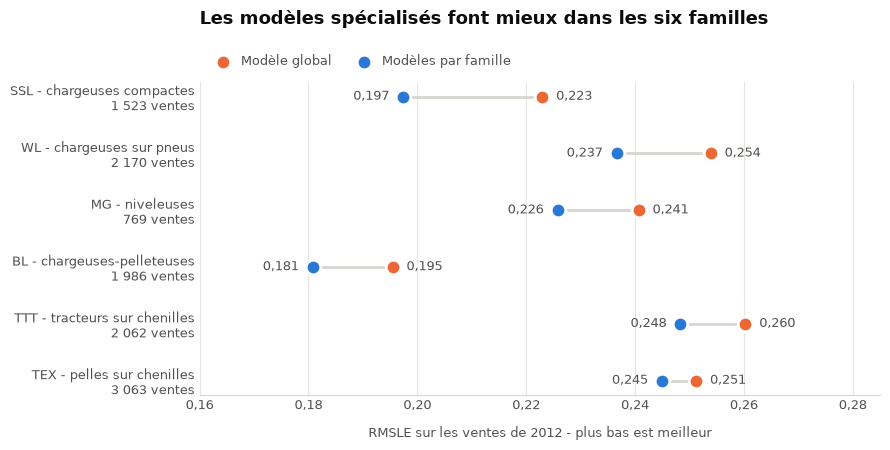

In [5]:
import matplotlib.pyplot as plt

# Palette catégorielle validée : les deux séries restent distinguables
# en vision normale comme en daltonisme.
COULEUR_GLOBAL = "#eb6834"
COULEUR_SEGMENTE = "#2a78d6"
ENCRE = "#0b0b0b"
ENCRE_SECONDAIRE = "#52514e"
TRAIT = "#d6d5d0"

NOMS = {"BL": "BL - chargeuses-pelleteuses", "MG": "MG - niveleuses",
        "SSL": "SSL - chargeuses compactes", "TEX": "TEX - pelles sur chenilles",
        "TTT": "TTT - tracteurs sur chenilles", "WL": "WL - chargeuses sur pneus"}

scores = pd.DataFrame(rapport["par_segment"]).sort_values("gain")
y = range(len(scores))

figure, axes = plt.subplots(figsize=(9, 4.6))
figure.patch.set_facecolor("white")
axes.set_facecolor("white")

# Le segment relie les deux mesures d'une même famille : c'est l'écart qu'on lit.
for position, (_, ligne) in zip(y, scores.iterrows()):
    axes.plot([ligne.rmsle_segmente, ligne.rmsle_global], [position, position],
              color=TRAIT, linewidth=2, zorder=1, solid_capstyle="round")

axes.scatter(scores.rmsle_global, y, s=110, color=COULEUR_GLOBAL, zorder=3,
             label="Modèle global", edgecolors="white", linewidths=2)
axes.scatter(scores.rmsle_segmente, y, s=110, color=COULEUR_SEGMENTE, zorder=3,
             label="Modèles par famille", edgecolors="white", linewidths=2)

for position, (_, ligne) in zip(y, scores.iterrows()):
    axes.annotate(f"{ligne.rmsle_segmente:.3f}".replace(".", ","),
                  (ligne.rmsle_segmente, position), textcoords="offset points",
                  xytext=(-10, 0), ha="right", va="center", fontsize=9, color=ENCRE_SECONDAIRE)
    axes.annotate(f"{ligne.rmsle_global:.3f}".replace(".", ","),
                  (ligne.rmsle_global, position), textcoords="offset points",
                  xytext=(10, 0), ha="left", va="center", fontsize=9, color=ENCRE_SECONDAIRE)

axes.set_yticks(list(y))
axes.set_yticklabels([f"{NOMS.get(s, s)}\n{n:,} ventes".replace(",", " ")
                      for s, n in zip(scores.segment, scores.n_test)],
                     fontsize=9, color=ENCRE)
axes.set_xlabel("RMSLE sur les ventes de 2012 - plus bas est meilleur",
                fontsize=9, color=ENCRE_SECONDAIRE, labelpad=10)
axes.set_xlim(0.16, 0.285)
axes.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda valeur, _: f"{valeur:.2f}".replace(".", ",")))
axes.set_title("Les modèles spécialisés font mieux dans les six familles",
               fontsize=13, color=ENCRE, loc="left", pad=42, fontweight="bold")
axes.grid(axis="x", color=TRAIT, linewidth=0.8, alpha=0.6)
axes.set_axisbelow(True)
for bord in ["top", "right", "left"]:
    axes.spines[bord].set_visible(False)
axes.spines["bottom"].set_color(TRAIT)
axes.tick_params(length=0, colors=ENCRE_SECONDAIRE, labelsize=9)
# Légende au-dessus du tracé : en bas à droite elle recouvrait la dernière famille.
axes.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncol=2, frameon=False,
            fontsize=9, labelcolor=ENCRE_SECONDAIRE, handletextpad=0.4, columnspacing=1.6)

figure.tight_layout()
FIGURE = ROOT / "docs/rmsle_par_famille.png"
figure.savefig(FIGURE, dpi=200, facecolor="white", bbox_inches="tight")
print("Figure enregistrée :", FIGURE)
plt.show()